In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("orthojax") is None:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "orthojax==0.1.5"]
    )

In [2]:
# BOOK_FIGURE_STYLE_CELL
import math

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib_inline
import numpy as np
import orthojax as ojax

matplotlib_inline.backend_inline.set_matplotlib_formats("svg")

FIGURE_SIZES = {
    "full_tall": (7.35, 5.50),
    "half_standard": (3.55, 2.55),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "purple": "#8F63B8",
}

mpl.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
        "axes.labelsize": 9,
        "axes.titlesize": 9,
        "axes.linewidth": 0.8,
        "axes.grid": False,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "legend.frameon": False,
        "lines.linewidth": 1.5,
    }
)


def label_panels(axes, labels=None, x=0.02, y=0.96):
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    for ax, label in zip(axes, labels):
        ax.text(
            x,
            y,
            label,
            fontsize=9,
            fontweight="bold",
            va="top",
            ha="left",
            transform=ax.transAxes,
        )


def finalize_axes(axes):
    for ax in np.atleast_1d(axes).ravel():
        ax.grid(False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(0.8)
        ax.spines["bottom"].set_linewidth(0.8)

# Numerical Construction of Orthonormal Polynomials


Classical probability distributions have familiar polynomial families, such as Legendre polynomials for a uniform input and Hermite polynomials for a Gaussian input. A general one-dimensional distribution may not. This notebook constructs the required orthonormal polynomials numerically from the probability law.

Let $\mu$ be a probability measure on an interval $I\subseteq\mathbb{R}$, and identify functions that agree $\mu$-almost everywhere. The inner product is

$$
\langle f,g\rangle_\mu=\int_I f(\xi)g(\xi)\,d\mu(\xi).
$$

Assume that $\mu$ has infinite support and finite moments of every order. If only degrees through $p$ are needed, it is enough for the moments through order $2p$ to be finite and for the support to contain at least $p+1$ points.

Orthogonality can also be defined with an unnormalized positive weight. For polynomial chaos, we first normalize that weight to a probability measure. This makes the constant orthonormal polynomial $\phi_0=1$ and gives the moment formulas from the preceding notebook their usual probabilistic interpretation.

## The three-term recurrence

Under the assumptions above, there is a unique monic polynomial $\pi_k$ of each degree $k\leq p$ that is orthogonal to every polynomial of lower degree. Set

$$
h_k=\langle\pi_k,\pi_k\rangle_\mu,\quad 0\leq k\leq p,
\qquad
\alpha_k=\frac{\langle\xi\pi_k,\pi_k\rangle_\mu}{h_k},\quad 0\leq k\leq p-1,
\qquad
\beta_k=\frac{h_k}{h_{k-1}},\quad 1\leq k\leq p.
$$

Starting from $\pi_0(\xi)=1$, and assuming $p\geq1$, the monic polynomials satisfy

$$
\pi_1(\xi)=(\xi-\alpha_0)\pi_0(\xi),
$$

and

$$
\pi_{k+1}(\xi)
=(\xi-\alpha_k)\pi_k(\xi)-\beta_k\pi_{k-1}(\xi),
\qquad 1\leq k\leq p-1.
$$

The orthonormal polynomials are $\phi_k=\pi_k/\sqrt{h_k}$. If $b_k=\sqrt{\beta_k}$, their recurrence is

$$
\phi_1(\xi)=\frac{\xi-\alpha_0}{b_1}\phi_0(\xi),
\qquad
\phi_{k+1}(\xi)
=\frac{(\xi-\alpha_k)\phi_k(\xi)-b_k\phi_{k-1}(\xi)}{b_{k+1}},
\qquad 1\leq k\leq p-1.
$$

The recurrence evaluates the basis without expanding high-degree polynomial coefficients. The numerical construction still depends on accurately integrating against $\mu$; the required quadrature accuracy should therefore be checked for the degrees being used {cite:p}`gautschi1994orthpol`.

## Checking the implementation against known families

The Orthojax implementation used below approximates the probability measure by quadrature and computes the recurrence coefficients of the resulting discrete measure {cite:p}`bilionis2024orthojax`. In an orthonormal Orthojax object, the entry `beta[k]` stores $b_k=\sqrt{\beta_k}$ for $k\geq1$, not the monic coefficient $\beta_k$ defined above. We use 64-bit arithmetic and first compare its coefficients with two known cases.

For $\Xi\sim\mathcal{U}[0,2]$,

$$
\alpha_k=1,
\qquad
b_k=\frac{k}{\sqrt{4k^2-1}},\quad k\geq1.
$$

For $\Xi\sim\mathcal{N}(0,1)$,

$$
\alpha_k=0,
\qquad
b_k=\sqrt{k},\quad k\geq1,
$$

which gives the orthonormal probabilists' Hermite basis $\phi_k=\operatorname{He}_k/\sqrt{k!}$ {cite:p}`gautschi1994orthpol`.

In [3]:
degree = 6
num_quadrature_points = 300

uniform_density = lambda xi: 0.5 * jnp.ones_like(xi)
uniform_poly = ojax.make_orthogonal_polynomial(
    degree,
    left=0.0,
    right=2.0,
    wf=uniform_density,
    ncap=num_quadrature_points,
)
normal_poly = ojax.make_hermite_polynomial(
    degree,
    ncap=num_quadrature_points,
)

k = np.arange(1, degree + 1, dtype=float)
# For an Orthojax normalized object, beta[1:] stores the coefficients b_k.
uniform_alpha_error = np.max(np.abs(np.asarray(uniform_poly.alpha[:-1]) - 1.0))
uniform_b_error = np.max(
    np.abs(np.asarray(uniform_poly.beta)[1:] - k / np.sqrt(4.0 * k**2 - 1.0))
)
normal_alpha_error = np.max(np.abs(np.asarray(normal_poly.alpha[:-1])))
normal_b_error = np.max(
    np.abs(np.asarray(normal_poly.beta)[1:] - np.sqrt(k))
)

print(f"Uniform: max alpha error = {uniform_alpha_error:.3e}")
print(f"Uniform: max b error     = {uniform_b_error:.3e}")
print(f"Normal:  max alpha error = {normal_alpha_error:.3e}")
print(f"Normal:  max b error     = {normal_b_error:.3e}")

assert uniform_alpha_error < 1.0e-4
assert uniform_b_error < 1.0e-4
assert normal_alpha_error < 1.0e-4
assert normal_b_error < 1.0e-4

Uniform: max alpha error = 1.276e-06
Uniform: max b error     = 6.571e-06
Normal:  max alpha error = 8.552e-08
Normal:  max b error     = 1.052e-06


The small discrepancies are quadrature-discretization and floating-point errors. Comparing with known recurrence coefficients checks both the probability-measure convention and the normalization returned by the software.

## A nonclassical probability law

Consider the symmetric Gaussian mixture

$$
\Xi\sim\tfrac12\mathcal{N}(-1,0.5^2)
       +\tfrac12\mathcal{N}(1,0.5^2).
$$

Its density is

$$
p_\Xi(\xi)
=\frac12\frac{e^{-(\xi+1)^2/(2\cdot0.5^2)}}{\sqrt{2\pi}\,0.5}
+\frac12\frac{e^{-(\xi-1)^2/(2\cdot0.5^2)}}{\sqrt{2\pi}\,0.5}.
$$

The mixture is not associated with one of the standard classical polynomial families. We construct its basis numerically and check the resulting Gram matrix with a separate Gauss--Hermite rule applied to each mixture component. This second quadrature rule is independent of the Fejér discretization used to construct the recurrence coefficients.

In [4]:
component_scale = 0.5


def gaussian_density(xi, mean, scale):
    normalizer = jnp.sqrt(2.0 * jnp.pi) * scale
    return jnp.exp(-0.5 * ((xi - mean) / scale) ** 2) / normalizer


def mixture_density(xi):
    return (
        0.5 * gaussian_density(xi, -1.0, component_scale)
        + 0.5 * gaussian_density(xi, 1.0, component_scale)
    )


mixture_poly = ojax.make_orthogonal_polynomial(
    degree,
    left=-math.inf,
    right=math.inf,
    wf=mixture_density,
    ncap=num_quadrature_points,
)

# Independent Gauss--Hermite quadrature for the two Gaussian components.
gh_nodes, gh_weights = np.polynomial.hermite.hermgauss(40)
validation_nodes = np.concatenate(
    (
        -1.0 + np.sqrt(2.0) * component_scale * gh_nodes,
        1.0 + np.sqrt(2.0) * component_scale * gh_nodes,
    )
)
validation_weights = np.concatenate(
    (
        0.5 * gh_weights / np.sqrt(np.pi),
        0.5 * gh_weights / np.sqrt(np.pi),
    )
)
mixture_values = np.asarray(mixture_poly(validation_nodes))
gram_matrix = np.einsum(
    "i,ij,ik->jk",
    validation_weights,
    mixture_values,
    mixture_values,
)
gram_error = np.max(np.abs(gram_matrix - np.eye(degree + 1)))

print(f"Maximum independent Gram-matrix error: {gram_error:.3e}")
assert gram_error < 1.0e-5

Maximum independent Gram-matrix error: 5.272e-07


The first panel below shows the probability density that defines the inner product. The second shows the first five orthonormal polynomials. Their magnitude can grow in the tails because orthonormality weights their products by the small probability density there.

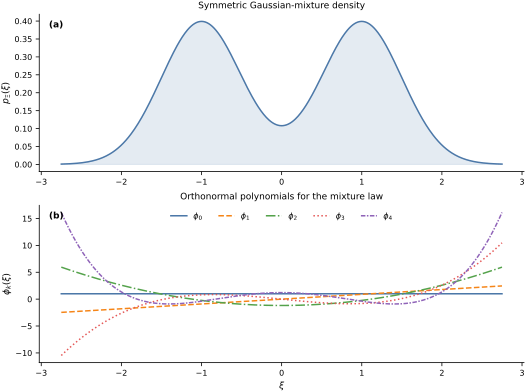

In [5]:
grid = np.linspace(-2.75, 2.75, 500)
density_values = np.asarray(mixture_density(grid))
basis_values = np.asarray(mixture_poly(grid))
line_styles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]
colors = list(BOOK_COLORS.values())

fig, axes = plt.subplots(
    2,
    1,
    figsize=FIGURE_SIZES["full_tall"],
    constrained_layout=True,
)
axes[0].plot(grid, density_values, color=BOOK_COLORS["blue"])
axes[0].fill_between(
    grid,
    0.0,
    density_values,
    color=BOOK_COLORS["blue"],
    alpha=0.15,
)
axes[0].set(
    ylabel=r"$p_\Xi(\xi)$",
    title="Symmetric Gaussian-mixture density",
)

for basis_index in range(5):
    axes[1].plot(
        grid,
        basis_values[:, basis_index],
        color=colors[basis_index],
        linestyle=line_styles[basis_index],
        label=rf"$\phi_{basis_index}$",
    )
axes[1].set(
    xlabel=r"$\xi$",
    ylabel=r"$\phi_k(\xi)$",
    title="Orthonormal polynomials for the mixture law",
)
axes[1].legend(loc="upper center", ncol=5)
label_panels(axes)
finalize_axes(axes)
plt.show()

## Projection under the mixture law

Let $Z=\cos(a\Xi)$ with $a=0.8$. Reusing the projection formulas from the preceding notebook, the degree-$p$ approximation is

$$
Z_p=\sum_{k=0}^{p}c_k\phi_k(\Xi),
\qquad
c_k=\mathbb{E}[\cos(a\Xi)\phi_k(\Xi)].
$$

Writing $\sigma=0.5$ for the common component scale, the symmetric mixture satisfies

$$
\mathbb{E}[\cos(t\Xi)]
=e^{-\sigma^2t^2/2}\cos(t).
$$

This identity gives exact reference values for the mean and variance of $Z$. The coefficients below are computed with the independent mixture quadrature used for the Gram-matrix check.

In [6]:
frequency = 0.8
response_values = np.cos(frequency * validation_nodes)
coefficients = np.einsum(
    "i,ij,i->j",
    validation_weights,
    mixture_values,
    response_values,
)

projection_mean = coefficients[0]
projection_variance = np.sum(coefficients[1:] ** 2)


def expected_cosine(frequency):
    damping = np.exp(-0.5 * component_scale**2 * frequency**2)
    return damping * np.cos(frequency)


exact_mean = expected_cosine(frequency)
exact_second_moment = 0.5 * (1.0 + expected_cosine(2.0 * frequency))
exact_variance = exact_second_moment - exact_mean**2

print(f"Degree-{degree} projection mean:     {projection_mean:.10f}")
print(f"Exact mean:                   {exact_mean:.10f}")
print(f"Degree-{degree} projection variance: {projection_variance:.10f}")
print(f"Exact variance:               {exact_variance:.10f}")

assert abs(projection_mean - exact_mean) < 1.0e-8
assert abs(projection_variance - exact_variance) < 1.0e-6

Degree-6 projection mean:     0.6431413520
Exact mean:                   0.6431413520
Degree-6 projection variance: 0.0757675569
Exact variance:               0.0757675988


The degree-six projection reproduces the reference mean to the displayed precision and captures the variance to the reported accuracy. The remaining variance is carried by coefficients of degree greater than six, together with the small numerical error in the constructed basis.

## Exercise

Replace the equal mixture weights by $0.7$ and $0.3$. Before computing, predict which symmetry properties of the density, recurrence coefficients, and basis functions will be lost. Reconstruct the basis, check its Gram matrix with the independent componentwise Gauss--Hermite rule, and compare the variance captured by degrees $p=0,1,\ldots,6$.

## Basis construction and quadrature

The probability law determines the orthonormal polynomial basis, while a chosen quadrature rule approximates the inner products and projection coefficients. The next notebook inserts such a basis into a Galerkin approximation of a dynamical system. Later, tensor products extend the same construction to several independent inputs.